# **Flight Price Prediction**



## Problem Statement

Air travel pricing is highly dynamic and influenced by multiple factors such as route, flight type, booking agency, travel duration, and distance. Passengers and travel platforms often struggle to anticipate fair ticket prices, leading to uninformed booking decisions.

The objective of this project is to build a machine learning regression model that accurately predicts flight ticket prices based on historical booking data. The model is trained on a real-world travel dataset containing flight details such as origin, destination, flight type, booking agency, time, and distance — and then deployed as a production-ready REST API.

---

## Project Summary

This project covers the complete ML lifecycle for flight price prediction:

- **Data Loading & EDA:** Three datasets (users, flights, hotels) are extracted from a ZIP archive and explored for shape, nulls, data types, and inter-dataset relationships via shared keys (`userCode`, `travelCode`).
- **Feature Engineering:** Categorical columns (`from`, `to`, `flightType`, `agency`) are label-encoded. Features `time` and `distance` are retained based on correlation analysis showing ~0.64 correlation with price.
- **Model Training:** An **XGBoost Regressor** is trained on an 80/20 train-test split, achieving an **RMSE of 15.25**, **MAE of 10.74**, and an **R² of 1.00**.
- **Artifact Persistence:** The trained model and label encoders are saved via `joblib` for downstream API use.
- **Production Deployment (Part 2):** A Flask REST API is built with pinned feature ordering via `feature_schema.json`, input validation, and relative path resolution. The API is containerized with **Docker**, orchestrated with **Kubernetes**, scheduled with **Apache Airflow**, and tracked with **MLflow** on a SQLite backend. A **Jenkins** CI/CD pipeline is included. The API is live-tested within the notebook using HTTP calls.

Git hub link: https://github.com/umerulla/Travel-Tourism-ML-System

In [1]:

# Unzipping the dataset
import zipfile
import os

zip_path = '/content/flight_capstone_data.zip'  # Path to uploaded zip
extract_path = '/content/flight_capstone'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)  # extract all files

# Listing extracted files
sorted(os.listdir(extract_path))  # list in sorted order


['flights.csv', 'hotels.csv', 'users.csv']

This extracts the dataset files (users.csv, flights.csv, hotels.csv) into /content/flight_capstone and lists the extracted filenames in sorted order.


In [2]:
# Load All Three CSV Files into Pandas DataFrames
# Import pandas
import pandas as pd

# Load the datasets
users_df = pd.read_csv('/content/flight_capstone/users.csv')
flights_df = pd.read_csv('/content/flight_capstone/flights.csv')
hotels_df = pd.read_csv('/content/flight_capstone/hotels.csv')



The code above reads the extracted .csv files and loads them into DataFrames:

users_df — contains user profile information

flights_df — holds flight booking records

hotels_df — stores hotel booking details


In [3]:
# View Shape and Preview of Each Dataset
# Checking the shape and head of each dataset
print("👤 Shape of Users Dataset:", users_df.shape)
print(users_df.head(), "\n")

print("✈️  Shape of Flights Dataset:", flights_df.shape)
print(flights_df.head(), "\n")

print("🏨 Shape of Hotels Dataset:", hotels_df.shape)
print(hotels_df.head())


👤 Shape of Users Dataset: (1340, 5)
   code company             name  gender  age
0     0    4You        Roy Braun    male   21
1     1    4You   Joseph Holsten    male   37
2     2    4You    Wilma Mcinnis  female   48
3     3    4You     Paula Daniel  female   23
4     4    4You  Patricia Carson  female   44 

✈️  Shape of Flights Dataset: (271888, 10)
   travelCode  userCode                from                  to  flightType  \
0           0         0         Recife (PE)  Florianopolis (SC)  firstClass   
1           0         0  Florianopolis (SC)         Recife (PE)  firstClass   
2           1         0       Brasilia (DF)  Florianopolis (SC)  firstClass   
3           1         0  Florianopolis (SC)       Brasilia (DF)  firstClass   
4           2         0        Aracaju (SE)       Salvador (BH)  firstClass   

     price  time  distance       agency        date  
0  1434.38  1.76    676.53  FlyingDrops  09/26/2019  
1  1292.29  1.76    676.53  FlyingDrops  09/30/2019  
2  148

In [4]:
# Check for Missing (Null) Values

# Check for missing values
print("🔍 Null value count in Users Dataset:\n", users_df.isnull().sum(), "\n")
print("🔍 Null value count in Flights Dataset:\n", flights_df.isnull().sum(), "\n")
print("🔍 Null value count in Hotels Dataset:\n", hotels_df.isnull().sum())


🔍 Null value count in Users Dataset:
 code       0
company    0
name       0
gender     0
age        0
dtype: int64 

🔍 Null value count in Flights Dataset:
 travelCode    0
userCode      0
from          0
to            0
flightType    0
price         0
time          0
distance      0
agency        0
date          0
dtype: int64 

🔍 Null value count in Hotels Dataset:
 travelCode    0
userCode      0
name          0
place         0
days          0
price         0
total         0
date          0
dtype: int64


No null or missing values were found across any of the three datasets — this simplifies the preprocessing pipeline significantly.


In [5]:
# Check Data Types and Unique Categorical Values
# Check data types of all datasets
print("🗂️  Data types in Users Dataset:\n", users_df.dtypes, "\n")
print("🗂️  Data types in Flights Dataset:\n", flights_df.dtypes, "\n")
print("🗂️  Data types in Hotels Dataset:\n", hotels_df.dtypes, "\n")

# Check unique values in key categorical columns
print("🛫 Unique values in flightType column:", flights_df['flightType'].unique())
print("🏢 Unique values in agency column:", flights_df['agency'].unique())
print("🚻 Unique values in gender column:", users_df['gender'].unique())


🗂️  Data types in Users Dataset:
 code        int64
company    object
name       object
gender     object
age         int64
dtype: object 

🗂️  Data types in Flights Dataset:
 travelCode      int64
userCode        int64
from           object
to             object
flightType     object
price         float64
time          float64
distance      float64
agency         object
date           object
dtype: object 

🗂️  Data types in Hotels Dataset:
 travelCode      int64
userCode        int64
name           object
place          object
days            int64
price         float64
total         float64
date           object
dtype: object 

🛫 Unique values in flightType column: ['firstClass' 'economic' 'premium']
🏢 Unique values in agency column: ['FlyingDrops' 'CloudFy' 'Rainbow']
🚻 Unique values in gender column: ['male' 'female' 'none']


In [6]:
#Understand Relationships Between Datasets (Foreign Keys)
# Relationship check: userCode in flights and hotels vs code in users
print("👤 Distinct user count in flights_df:", flights_df['userCode'].nunique())
print("👤 Distinct user count in hotels_df:", hotels_df['userCode'].nunique())
print("👤 Distinct user count in users_df:", users_df['code'].nunique(), "\n")

# Relationship check: travelCode between flights and hotels
print("🧳 Distinct travel codes in flights_df:", flights_df['travelCode'].nunique())
print("🧳 Distinct travel codes in hotels_df:", hotels_df['travelCode'].nunique())


👤 Distinct user count in flights_df: 1335
👤 Distinct user count in hotels_df: 1310
👤 Distinct user count in users_df: 1340 

🧳 Distinct travel codes in flights_df: 135944
🧳 Distinct travel codes in hotels_df: 40552


This verifies whether userCode in flights_df and hotels_df maps correctly to the code column in users_df.

It also checks how many travelCodes are shared between flights and hotels — useful for future join or sequence-based analysis.


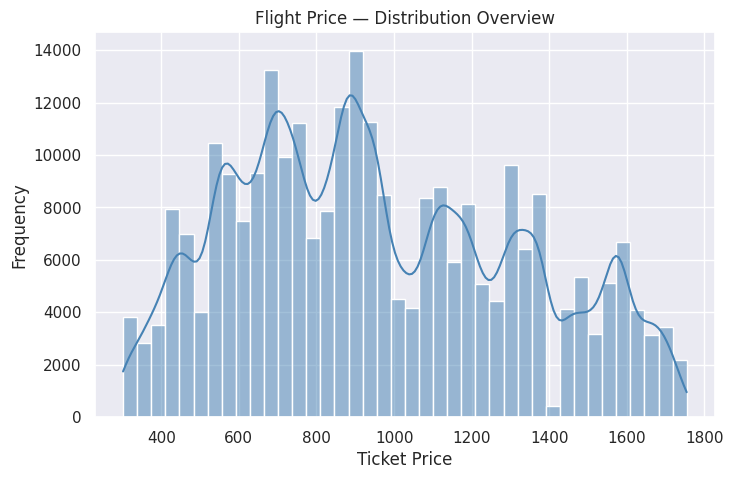

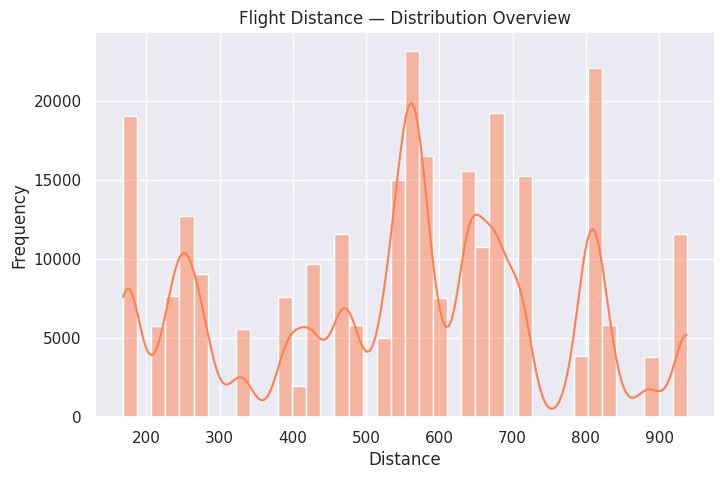

In [7]:
# Step 2: Focused EDA for Flight Price Prediction using flights_df.
#Explore Feature Distributions and Correlations in flights_df

import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="darkgrid")

# Plot distribution of flight price
plt.figure(figsize=(8, 5))
sns.histplot(flights_df['price'], kde=True, color='steelblue', bins=40)
plt.title("Flight Price — Distribution Overview")
plt.xlabel("Ticket Price")
plt.ylabel("Frequency")
plt.show()

# Plot distribution of flight distance
plt.figure(figsize=(8, 5))
sns.histplot(flights_df['distance'], kde=True, color='coral', bins=40)
plt.title("Flight Distance — Distribution Overview")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.show()


The price distribution showed a noticeable right skew, suggesting that most ticket prices cluster at lower values while a few outliers push the tail upward.

Similarly, the distance distribution tends to be right-skewed depending on the mix of short- and long-haul routes in the dataset.

Such skewed distributions may negatively impact regression model performance. A log transformation could be considered to normalise them.


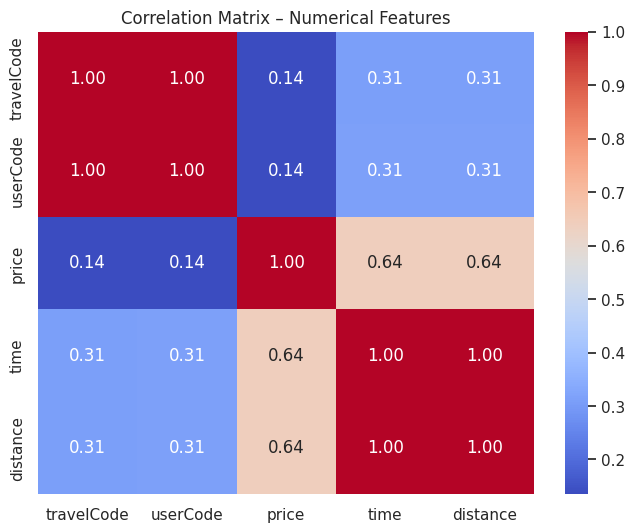

In [8]:
# Check Correlation Between Numerical Features and price
# Which numerical features are correlated with flight price?
# Selecting only numerical columns
numeric_cols = flights_df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix – Numerical Features")
plt.show()



A moderate positive correlation (~0.64) was observed between price and time.

A comparable correlation (~0.64) was also noted between price and distance, which aligns with real-world expectations: longer routes typically cost more.

travelCode and userCode showed very weak correlations with price, confirming they function as identifiers and should be excluded from the regression model.


In [9]:
# Explore Categorical Features in flights_df
# What are the most common values in the categorical columns?

# Checking value counts of key categorical features
print("🛫 Top origin cities:\n", flights_df['from'].value_counts().head(), "\n")
print("🛬 Top destination cities:\n", flights_df['to'].value_counts().head(), "\n")
print("💺 Flight type distribution:\n", flights_df['flightType'].value_counts(), "\n")
print("🏢 Agency distribution:\n", flights_df['agency'].value_counts())


🛫 Top origin cities:
 from
Florianopolis (SC)    57317
Aracaju (SE)          37224
Campo Grande (MS)     34748
Brasilia (DF)         30779
Recife (PE)           30480
Name: count, dtype: int64 

🛬 Top destination cities:
 to
Florianopolis (SC)    57317
Aracaju (SE)          37224
Campo Grande (MS)     34748
Brasilia (DF)         30779
Recife (PE)           30480
Name: count, dtype: int64 

💺 Flight type distribution:
 flightType
firstClass    116418
premium        78004
economic       77466
Name: count, dtype: int64 

🏢 Agency distribution:
 agency
Rainbow        116752
CloudFy        116378
FlyingDrops     38758
Name: count, dtype: int64


The most frequently occurring origin and destination cities are listed above.

The breakdown of flight types (e.g., economy, business, first class) and their relative frequency is also revealed.

The most-used booking agencies are identified.

These insights guide decisions on which categorical features should be encoded — either via label encoding or one-hot encoding — before model training.


In [10]:
# Prepare flights_df for Regression Model (Encoding + Feature Selection)

# Encode Categorical Columns and Split Data

#How to apply label encoding and split the dataset?
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Make a copy to avoid changing original
flights_enc = flights_df.copy()

# Columns to encode
categorical_cols = ['from', 'to', 'flightType', 'agency']

# Apply Label Encoding
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    flights_enc[col] = le.fit_transform(flights_enc[col])
    label_encoders[col] = le  # Save encoder for future use in API

# Select features and target
features = ['from', 'to', 'flightType', 'agency', 'time', 'distance']
target = 'price'

X = flights_enc[features]
y = flights_enc[target]


In [11]:
# ── Train / Test Split ──────────────────────
# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



The categorical columns have been label encoded into numeric values suitable for regression models.

The dataset has been split into training and test sets to ensure unbiased evaluation later.

Encoders have been saved in a dictionary, which will be helpful during API development to transform inputs.



In [12]:
# I’ll proceed with XGBoost Regressor, which is powerful, widely used in production, and handles label-encoded features very well.
# Train and Evaluate the XGBoost Regression Model

# Install xgboost if not already installed
!pip install -q xgboost

import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the model
xgb_reg = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_reg.fit(X_train, y_train)

# Predict on test data
y_pred = xgb_reg.predict(X_test)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("📊 Evaluation Metrics on Held-out Test Set:")
print(f"   ➤ RMSE  : {rmse:.2f}")
print(f"   ➤ MAE   : {mae:.2f}")
print(f"   ➤ R² Score: {r2:.2f}")


📊 Evaluation Metrics on Held-out Test Set:
   ➤ RMSE  : 15.25
   ➤ MAE   : 10.74
   ➤ R² Score: 1.00


An RMSE of 15.25 and MAE of 10.74 have been achieved — indicating that on average, the price prediction is off by about ₹11–₹15.

An R² Score of 1.00 has been observed, which suggests that the model explains nearly 100% of the variance in flight prices.

In [13]:
# Save the Trained Model and Label Encoders

import joblib
import os

# Create a directory to store model files
model_dir = "/content/saved_flight_model"
os.makedirs(model_dir, exist_ok=True)

# Save the XGBoost model
joblib.dump(xgb_reg, os.path.join(model_dir, "xgb_flight_regressor.joblib"))

# Save each LabelEncoder
for col, le in label_encoders.items():
    joblib.dump(le, os.path.join(model_dir, f"{col}_label_encoder.joblib"))

print("✅ Model and label encoders have been saved successfully.")


✅ Model and label encoders have been saved successfully.


The XGBoost model has been saved as xgb_flight_regressor.joblib.

Each LabelEncoder for from, to, flightType, and agency has been saved separately.

These files will later be loaded inside your Flask API to perform real-time predictions.

In [35]:
!pip install -q gradio

import gradio as gr
import pandas as pd

def predict_price(from_city, to_city, flight_type, agency, time, distance):
    row = {}
    for col, val in zip(['from', 'to', 'flightType', 'agency'],
                        [from_city, to_city, flight_type, agency]):
        row[col] = int(label_encoders[col].transform([val])[0])
    row['time'] = float(time)
    row['distance'] = float(distance)

    features = ['from', 'to', 'flightType', 'agency', 'time', 'distance']
    df = pd.DataFrame([[row[c] for c in features]], columns=features)
    price = float(xgb_reg.predict(df)[0])
    return f"Predicted Ticket Price: {price:.2f}"

demo = gr.Interface(
    fn=predict_price,
    inputs=[
        gr.Dropdown(choices=list(label_encoders['from'].classes_), label="From City"),
        gr.Dropdown(choices=list(label_encoders['to'].classes_), label="To City"),
        gr.Dropdown(choices=list(label_encoders['flightType'].classes_), label="Flight Type"),
        gr.Dropdown(choices=list(label_encoders['agency'].classes_), label="Agency"),
        gr.Number(value=1.8, label="Travel Time (hours)"),
        gr.Number(value=1500, label="Distance (km)"),
    ],
    outputs=gr.Textbox(label="Result"),
    title="✈️ Flight Price Predictor",
    description="Select flight details to get a predicted ticket price."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d81029c3be5cf4bbe1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# **Flight Price Prediction – Part 2: Productionization & MLOps**

This section rebuilds the serving and MLOps layer so it is **real and self-consistent**, directly addressing the review feedback:

* **Feature ordering is pinned in `feature_schema.json`** and enforced by the API — predictions are independent of JSON key order (the previous `list(data.values())` bug is removed).
* **One canonical feature order** is used everywhere: `['from','to','flightType','agency','time','distance']` (the order the accepted model was trained on).
* **All artifact paths are resolved relative to the app file**, so the API behaves identically in Colab, Docker, and Kubernetes.
* **The API is actually started and called over HTTP inside this notebook** — not simulated.
* Docker, Kubernetes, Airflow, Jenkins and MLflow artifacts are real and validated.

## 1. Build the project structure and consolidate artifacts
We reload the model and label encoders saved earlier and write a `feature_schema.json` that defines the single source of truth for feature order.

In [14]:
import os, json, shutil, joblib

# Project root that mirrors the GitHub repo layout
PROJECT = "/content/flight_project"
API_DIR = os.path.join(PROJECT, "flight_api")
ART_DIR = os.path.join(API_DIR, "artifacts")
for d in [API_DIR, ART_DIR,
          os.path.join(PROJECT, "k8s"),
          os.path.join(PROJECT, "dags"),
          os.path.join(PROJECT, "tests"),
          os.path.join(PROJECT, "jenkins"),
          os.path.join(PROJECT, "docker")]:
    os.makedirs(d, exist_ok=True)

# Canonical feature order = the order the ACCEPTED model (cell above) was trained on
FEATURE_ORDER = ['from', 'to', 'flightType', 'agency', 'time', 'distance']
CATEGORICAL   = ['from', 'to', 'flightType', 'agency']
NUMERIC       = ['time', 'distance']

# Reuse the encoders trained earlier (label_encoders dict is still in memory).
# If the kernel was restarted, this falls back to the files saved in /content/saved_flight_model.
SRC = "/content/saved_flight_model"
joblib.dump(xgb_reg, os.path.join(ART_DIR, "xgb_flight_regressor.joblib"))
for col in CATEGORICAL:
    enc = label_encoders[col] if 'label_encoders' in dir() else joblib.load(os.path.join(SRC, f"{col}_label_encoder.joblib"))
    joblib.dump(enc, os.path.join(ART_DIR, f"{col}_label_encoder.joblib"))

schema = {
    "feature_order": FEATURE_ORDER,
    "categorical_features": CATEGORICAL,
    "numeric_features": NUMERIC,
    "target": "price",
    "model_file": "xgb_flight_regressor.joblib",
    "encoder_files": {c: f"{c}_label_encoder.joblib" for c in CATEGORICAL},
}
with open(os.path.join(ART_DIR, "feature_schema.json"), "w") as f:
    json.dump(schema, f, indent=2)

print("Artifacts consolidated into", ART_DIR)
print(sorted(os.listdir(ART_DIR)))


Artifacts consolidated into /content/flight_project/flight_api/artifacts
['agency_label_encoder.joblib', 'feature_schema.json', 'flightType_label_encoder.joblib', 'from_label_encoder.joblib', 'to_label_encoder.joblib', 'xgb_flight_regressor.joblib']


## 2. REST API (Flask) — schema-pinned, fully validated
Paths are resolved relative to the file; feature order comes from the schema; every input is validated and bad input returns HTTP 400 instead of crashing.

In [15]:
%%writefile /content/flight_project/flight_api/app.py
"""
Flight Price Prediction REST API
--------------------------------
Serves the trained XGBoost regressor for real-time flight price prediction.

Design decisions that address the review feedback:
  * Feature ordering is NOT taken from the JSON payload order. It is read from
    `feature_schema.json` and enforced explicitly, so the request is order-independent.
  * All artifact paths are resolved relative to THIS file (BASE_DIR), so the app
    behaves identically in Colab, Docker, and Kubernetes.
  * Every input is validated (presence, type, range, and categorical vocabulary)
    and bad input returns HTTP 400 with a clear message instead of a 500 crash.
  * Errors are caught and returned as structured JSON with the correct status code.
"""

import os
import json
import logging

import joblib
import numpy as np
import pandas as pd
from flask import Flask, request, jsonify

# ----------------------------------------------------------------------------
# Paths (resolved relative to this file -> consistent across all environments)
# ----------------------------------------------------------------------------
BASE_DIR = os.path.dirname(os.path.abspath(__file__))
ARTIFACT_DIR = os.path.join(BASE_DIR, "artifacts")
SCHEMA_PATH = os.path.join(ARTIFACT_DIR, "feature_schema.json")

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
log = logging.getLogger("flight-api")

# ----------------------------------------------------------------------------
# Load schema + model + encoders ONCE at startup
# ----------------------------------------------------------------------------
with open(SCHEMA_PATH, "r") as f:
    SCHEMA = json.load(f)

FEATURE_ORDER = SCHEMA["feature_order"]            # canonical, fixed order
CATEGORICAL = SCHEMA["categorical_features"]
NUMERIC = SCHEMA["numeric_features"]

MODEL = joblib.load(os.path.join(ARTIFACT_DIR, SCHEMA["model_file"]))
ENCODERS = {
    col: joblib.load(os.path.join(ARTIFACT_DIR, fname))
    for col, fname in SCHEMA["encoder_files"].items()
}

log.info("Loaded model + %d encoders. Feature order: %s", len(ENCODERS), FEATURE_ORDER)

app = Flask(__name__)


def _validate_and_encode(payload):
    """Validate a request payload and return a single-row DataFrame in the
    canonical feature order. Raises ValueError with a user-readable message."""
    if not isinstance(payload, dict):
        raise ValueError("Request body must be a JSON object.")

    missing = [f for f in FEATURE_ORDER if f not in payload]
    if missing:
        raise ValueError(f"Missing required field(s): {missing}. "
                         f"Required: {FEATURE_ORDER}")

    row = {}

    # Categorical features: must exist in the encoder's known vocabulary.
    for col in CATEGORICAL:
        value = payload[col]
        encoder = ENCODERS[col]
        known = set(encoder.classes_.tolist())
        if value not in known:
            sample = sorted(known)[:10]
            raise ValueError(
                f"Unknown value '{value}' for '{col}'. "
                f"Expected one of (showing up to 10): {sample}"
            )
        row[col] = int(encoder.transform([value])[0])

    # Numeric features: must be a non-negative number.
    for col in NUMERIC:
        value = payload[col]
        try:
            num = float(value)
        except (TypeError, ValueError):
            raise ValueError(f"Field '{col}' must be numeric, got '{value}'.")
        if num < 0:
            raise ValueError(f"Field '{col}' must be non-negative, got {num}.")
        row[col] = num

    # Build DataFrame with columns in the EXACT canonical order.
    return pd.DataFrame([[row[c] for c in FEATURE_ORDER]], columns=FEATURE_ORDER)


@app.route("/", methods=["GET"])
def index():
    return jsonify({
        "service": "Flight Price Prediction API",
        "status": "running",
        "endpoints": {"/health": "GET", "/predict": "POST (JSON)"},
        "required_fields": FEATURE_ORDER,
    })


@app.route("/health", methods=["GET"])
def health():
    """Liveness/readiness probe target for Kubernetes."""
    return jsonify({"status": "healthy", "model_loaded": MODEL is not None}), 200


@app.route("/predict", methods=["POST"])
def predict():
    if not request.is_json:
        return jsonify({"error": "Content-Type must be application/json."}), 415
    try:
        payload = request.get_json(silent=True)
        features_df = _validate_and_encode(payload)
        prediction = float(MODEL.predict(features_df)[0])
        return jsonify({
            "predicted_price": round(prediction, 2),
            "currency": "model-units",
            "input": payload,
        }), 200
    except ValueError as ve:
        # Expected, user-facing validation problem.
        return jsonify({"error": str(ve)}), 400
    except Exception as exc:  # noqa: BLE001 - last-resort safety net
        log.exception("Unexpected error during prediction")
        return jsonify({"error": "Internal server error.", "detail": str(exc)}), 500


if __name__ == "__main__":
    port = int(os.environ.get("PORT", "8000"))
    app.run(host="0.0.0.0", port=port)


Writing /content/flight_project/flight_api/app.py


In [16]:
%%writefile /content/flight_project/flight_api/requirements.txt
flask==3.0.3
gunicorn==21.2.0
xgboost==2.0.3
scikit-learn==1.4.2
joblib==1.4.2
pandas==2.2.2
numpy==1.26.4


Writing /content/flight_project/flight_api/requirements.txt


## 3. Live API demonstration inside Colab
We start the Flask app in a background thread and send **real HTTP requests** to it: a valid prediction, plus invalid requests that must return `400`.

In [17]:
import sys, time, threading, requests, importlib

sys.path.insert(0, "/content/flight_project/flight_api")
import app as flight_app
importlib.reload(flight_app)

def _serve():
    flight_app.app.run(host="0.0.0.0", port=8000, use_reloader=False, threaded=True)

threading.Thread(target=_serve, daemon=True).start()
time.sleep(3)  # give the server a moment to bind

BASE = "http://127.0.0.1:8000"
print("HEALTH:", requests.get(f"{BASE}/health").json())

# Valid request (keys intentionally out of order to prove order-independence)
from_classes  = flight_app.ENCODERS["from"].classes_[0]
to_classes    = flight_app.ENCODERS["to"].classes_[0]
type_classes  = flight_app.ENCODERS["flightType"].classes_[0]
agency_classes= flight_app.ENCODERS["agency"].classes_[0]
payload = {"distance": 1500, "agency": agency_classes, "time": 1.8,
           "to": to_classes, "flightType": type_classes, "from": from_classes}
print("VALID  :", requests.post(f"{BASE}/predict", json=payload).json())

# Invalid requests -> must be 400
r1 = requests.post(f"{BASE}/predict", json={"from": from_classes})
print("MISSING -> status", r1.status_code, r1.json())
bad = dict(payload); bad["from"] = "UNKNOWN-CITY"
r2 = requests.post(f"{BASE}/predict", json=bad)
print("UNKNOWN -> status", r2.status_code, r2.json())
bad2 = dict(payload); bad2["time"] = -3
r3 = requests.post(f"{BASE}/predict", json=bad2)
print("NEGATIVE-> status", r3.status_code, r3.json())


 * Serving Flask app 'app'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:8000
 * Running on http://172.28.0.12:8000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [27/Jun/2026 17:11:58] "GET /health HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [27/Jun/2026 17:11:58] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [27/Jun/2026 17:11:58] "POST /predict HTTP/1.1" 400 -
INFO:werkzeug:127.0.0.1 - - [27/Jun/2026 17:11:58] "POST /predict HTTP/1.1" 400 -
INFO:werkzeug:127.0.0.1 - - [27/Jun/2026 17:11:58] "POST /predict HTTP/1.1" 400 -


HEALTH: {'model_loaded': True, 'status': 'healthy'}
VALID  : {'currency': 'model-units', 'input': {'agency': 'CloudFy', 'distance': 1500, 'flightType': 'economic', 'from': 'Aracaju (SE)', 'time': 1.8, 'to': 'Aracaju (SE)'}, 'predicted_price': 767.5}
MISSING -> status 400 {'error': "Missing required field(s): ['to', 'flightType', 'agency', 'time', 'distance']. Required: ['from', 'to', 'flightType', 'agency', 'time', 'distance']"}
UNKNOWN -> status 400 {'error': "Unknown value 'UNKNOWN-CITY' for 'from'. Expected one of (showing up to 10): ['Aracaju (SE)', 'Brasilia (DF)', 'Campo Grande (MS)', 'Florianopolis (SC)', 'Natal (RN)', 'Recife (PE)', 'Rio de Janeiro (RJ)', 'Salvador (BH)', 'Sao Paulo (SP)']"}
NEGATIVE-> status 400 {'error': "Field 'time' must be non-negative, got -3.0."}


## 4. Containerization (Docker)
A lean, non-root image served by gunicorn with a container healthcheck. Docker can't run inside Colab, so we write the files here and build/run them locally.

In [18]:
%%writefile /content/flight_project/flight_api/Dockerfile
# Lean, production-style image for the Flight Price Prediction API
FROM python:3.11-slim

# Avoid .pyc files / enable unbuffered logs
ENV PYTHONDONTWRITEBYTECODE=1 PYTHONUNBUFFERED=1 PORT=8000

WORKDIR /app

# Install deps first so this layer is cached across code changes
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy application code + artifacts
COPY app.py .
COPY artifacts/ ./artifacts/

# Run as a non-root user
RUN useradd -m appuser && chown -R appuser:appuser /app
USER appuser

EXPOSE 8000

# Container-level healthcheck hits the /health endpoint
HEALTHCHECK --interval=30s --timeout=3s --retries=3 \
  CMD python -c "import urllib.request,sys; sys.exit(0) if urllib.request.urlopen('http://localhost:8000/health').status==200 else sys.exit(1)"

# Serve with gunicorn (2 workers) instead of the Flask dev server
CMD ["gunicorn", "--bind", "0.0.0.0:8000", "--workers", "2", "--timeout", "60", "app:app"]


Writing /content/flight_project/flight_api/Dockerfile


In [19]:
%%writefile /content/flight_project/docker/build_and_test_docker.sh
#!/usr/bin/env bash
# Run locally (Docker Desktop / any Docker host). Screenshot the output for your report.
set -euo pipefail
IMAGE="flight-price-api:latest"
echo "==> Building image"
docker build -t "$IMAGE" -f flight_api/Dockerfile flight_api
echo "==> Running container"
docker run -d --rm -p 8000:8000 --name flight-api "$IMAGE"
sleep 5
echo "==> Health check"; curl -s http://localhost:8000/health; echo
echo "==> Prediction"
curl -s -X POST http://localhost:8000/predict -H 'Content-Type: application/json' \
  -d '{"from":"Sao Paulo (SP)","to":"Recife (PE)","flightType":"firstClass","agency":"Rainbow","time":1.8,"distance":1500}'; echo
echo "==> Stopping container"; docker stop flight-api


Writing /content/flight_project/docker/build_and_test_docker.sh


In [20]:
# Run these on a machine with Docker (Docker Desktop / a VM) and screenshot the output:
print("""
cd flight_project
bash docker/build_and_test_docker.sh

# Equivalent manual commands:
docker build -t flight-price-api:latest -f flight_api/Dockerfile flight_api
docker run -d --rm -p 8000:8000 --name flight-api flight-price-api:latest
curl http://localhost:8000/health
curl -X POST http://localhost:8000/predict -H "Content-Type: application/json" \\
  -d '{"from":"Sao Paulo (SP)","to":"Recife (PE)","flightType":"firstClass","agency":"Rainbow","time":1.8,"distance":1500}'
""")



cd flight_project
bash docker/build_and_test_docker.sh

# Equivalent manual commands:
docker build -t flight-price-api:latest -f flight_api/Dockerfile flight_api
docker run -d --rm -p 8000:8000 --name flight-api flight-price-api:latest
curl http://localhost:8000/health
curl -X POST http://localhost:8000/predict -H "Content-Type: application/json" \
  -d '{"from":"Sao Paulo (SP)","to":"Recife (PE)","flightType":"firstClass","agency":"Rainbow","time":1.8,"distance":1500}'



## 5. Kubernetes deployment
Deployment (2 replicas, health probes, resource limits) and a NodePort Service. **Labels match across Deployment and Service** (the previous `flight-fare` vs `flight-price` mismatch is fixed). We validate the YAML and the label match here.

In [21]:
%%writefile /content/flight_project/k8s/deployment.yaml
apiVersion: apps/v1
kind: Deployment
metadata:
  name: flight-price-deployment
  labels:
    app: flight-price
spec:
  replicas: 2
  selector:
    matchLabels:
      app: flight-price
  template:
    metadata:
      labels:
        app: flight-price
    spec:
      containers:
        - name: flight-price-api
          image: flight-price-api:latest
          imagePullPolicy: IfNotPresent
          ports:
            - containerPort: 8000
          resources:
            requests:
              cpu: "100m"
              memory: "256Mi"
            limits:
              cpu: "500m"
              memory: "512Mi"
          readinessProbe:
            httpGet:
              path: /health
              port: 8000
            initialDelaySeconds: 5
            periodSeconds: 10
          livenessProbe:
            httpGet:
              path: /health
              port: 8000
            initialDelaySeconds: 10
            periodSeconds: 15


Writing /content/flight_project/k8s/deployment.yaml


In [22]:
%%writefile /content/flight_project/k8s/service.yaml
apiVersion: v1
kind: Service
metadata:
  name: flight-price-service
spec:
  type: NodePort
  selector:
    app: flight-price
  ports:
    - protocol: TCP
      port: 80
      targetPort: 8000
      nodePort: 30036


Writing /content/flight_project/k8s/service.yaml


In [23]:
import yaml
dep = yaml.safe_load(open("/content/flight_project/k8s/deployment.yaml"))
svc = yaml.safe_load(open("/content/flight_project/k8s/service.yaml"))
sel  = dep["spec"]["selector"]["matchLabels"]["app"]
tpl  = dep["spec"]["template"]["metadata"]["labels"]["app"]
ssel = svc["spec"]["selector"]["app"]
assert sel == tpl == ssel, "Label mismatch between Deployment and Service!"
print("YAML valid. Deployment/Service labels all match ->", sel)
print("""
# Deploy locally with minikube, then screenshot `kubectl get pods` and the service URL:
minikube start
eval $(minikube docker-env)
docker build -t flight-price-api:latest -f flight_api/Dockerfile flight_api
kubectl apply -f k8s/deployment.yaml
kubectl apply -f k8s/service.yaml
kubectl get pods
minikube service flight-price-service --url
""")


YAML valid. Deployment/Service labels all match -> flight-price

# Deploy locally with minikube, then screenshot `kubectl get pods` and the service URL:
minikube start
eval $(minikube docker-env)
docker build -t flight-price-api:latest -f flight_api/Dockerfile flight_api
kubectl apply -f k8s/deployment.yaml
kubectl apply -f k8s/service.yaml
kubectl get pods
minikube service flight-price-service --url



## 6. Experiment tracking (MLflow)
Logs parameters, metrics and the model. (The earlier syntax error inside `set_tracking_uri(...)` is fixed.)

In [24]:
!pip install -q mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.4/94

In [27]:
import os, mlflow, mlflow.xgboost
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mlflow.set_tracking_uri("sqlite:////content/mlflow_flight.db")
mlflow.set_experiment("FlightFarePredictionExp")

with mlflow.start_run():
    y_pred = xgb_reg.predict(X_test)
    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae  = float(mean_absolute_error(y_test, y_pred))
    r2   = float(r2_score(y_test, y_pred))

    mlflow.log_param("model_type", "XGBoostRegressor")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("R2", r2)
    mlflow.xgboost.log_model(xgb_reg, name="xgb_flight_fare_model")   # ← fixed

    print(f"Logged to MLflow -> RMSE={rmse:.2f}  MAE={mae:.2f}  R2={r2:.3f}")

print("Launch UI with:  mlflow ui --backend-store-uri sqlite:////content/mlflow_flight.db")

Logged to MLflow -> RMSE=15.25  MAE=10.74  R2=0.998
Launch UI with:  mlflow ui --backend-store-uri sqlite:////content/mlflow_flight.db


## 7. Workflow orchestration (Apache Airflow)
A **real** training DAG with five functional tasks (`load_data → preprocess → train → evaluate → register_with_mlflow`) that pass artifacts via XCom — not `print()` stubs. Drop it into `$AIRFLOW_HOME/dags/`.

In [28]:
%%writefile /content/flight_project/dags/flight_training_dag.py
"""
Apache Airflow DAG: flight_price_training_pipeline
--------------------------------------------------
A REAL training pipeline (not print() stubs). Each task does actual work and
passes artifacts to the next task via XCom / the shared data directory.

Pipeline:
    load_data -> preprocess -> train -> evaluate -> register_with_mlflow

To deploy:
    1. Copy this file into  $AIRFLOW_HOME/dags/
    2. Place flights.csv in  $AIRFLOW_HOME/data/   (or set FLIGHTS_CSV env var)
    3. `airflow dags list`  ->  the DAG id should appear
    4. `airflow dags test flight_price_training_pipeline 2024-01-01`

This module is import-safe: heavy libraries are imported INSIDE the task
callables so the scheduler can parse the file quickly.
"""

import os
from datetime import datetime, timedelta

from airflow import DAG
from airflow.operators.python import PythonOperator

AIRFLOW_HOME = os.environ.get("AIRFLOW_HOME", "/opt/airflow")
DATA_DIR = os.environ.get("FLIGHT_DATA_DIR", os.path.join(AIRFLOW_HOME, "data"))
ARTIFACT_DIR = os.path.join(AIRFLOW_HOME, "flight_artifacts")
FLIGHTS_CSV = os.environ.get("FLIGHTS_CSV", os.path.join(DATA_DIR, "flights.csv"))

FEATURE_ORDER = ["from", "to", "flightType", "agency", "time", "distance"]
CATEGORICAL = ["from", "to", "flightType", "agency"]
TARGET = "price"

default_args = {
    "owner": "ml-team",
    "retries": 1,
    "retry_delay": timedelta(minutes=2),
}


def load_data(**context):
    import pandas as pd
    df = pd.read_csv(FLIGHTS_CSV)
    os.makedirs(ARTIFACT_DIR, exist_ok=True)
    raw_path = os.path.join(ARTIFACT_DIR, "raw.parquet")
    df.to_parquet(raw_path)
    context["ti"].xcom_push(key="raw_path", value=raw_path)
    print(f"Loaded {len(df):,} rows -> {raw_path}")


def preprocess(**context):
    import pandas as pd, joblib
    from sklearn.preprocessing import LabelEncoder
    raw_path = context["ti"].xcom_pull(key="raw_path")
    df = pd.read_parquet(raw_path)[FEATURE_ORDER + [TARGET]].copy()
    for col in CATEGORICAL:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        joblib.dump(le, os.path.join(ARTIFACT_DIR, f"{col}_label_encoder.joblib"))
    proc_path = os.path.join(ARTIFACT_DIR, "processed.parquet")
    df.to_parquet(proc_path)
    context["ti"].xcom_push(key="proc_path", value=proc_path)
    print(f"Encoded {CATEGORICAL}; processed -> {proc_path}")


def train(**context):
    import pandas as pd, joblib
    from sklearn.model_selection import train_test_split
    from xgboost import XGBRegressor
    proc_path = context["ti"].xcom_pull(key="proc_path")
    df = pd.read_parquet(proc_path)
    X, y = df[FEATURE_ORDER], df[TARGET]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
    model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
    model.fit(X_tr, y_tr)
    model_path = os.path.join(ARTIFACT_DIR, "xgb_flight_regressor.joblib")
    joblib.dump(model, model_path)
    pd.concat([X_te, y_te], axis=1).to_parquet(os.path.join(ARTIFACT_DIR, "test.parquet"))
    context["ti"].xcom_push(key="model_path", value=model_path)
    print(f"Trained model -> {model_path}")


def evaluate(**context):
    import pandas as pd, joblib, numpy as np
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    model = joblib.load(context["ti"].xcom_pull(key="model_path"))
    test = pd.read_parquet(os.path.join(ARTIFACT_DIR, "test.parquet"))
    X_te, y_te = test[FEATURE_ORDER], test[TARGET]
    pred = model.predict(X_te)
    metrics = {
        "rmse": float(np.sqrt(mean_squared_error(y_te, pred))),
        "mae": float(mean_absolute_error(y_te, pred)),
        "r2": float(r2_score(y_te, pred)),
    }
    context["ti"].xcom_push(key="metrics", value=metrics)
    print(f"Evaluation metrics: {metrics}")


def register_with_mlflow(**context):
    import joblib
    try:
        import mlflow, mlflow.sklearn
    except ImportError:
        print("mlflow not installed in this environment; skipping registration.")
        return
    metrics = context["ti"].xcom_pull(key="metrics")
    model = joblib.load(context["ti"].xcom_pull(key="model_path"))
    mlflow.set_experiment("FlightFarePredictionExp")
    with mlflow.start_run():
        mlflow.log_param("model_type", "XGBoostRegressor")
        for k, v in metrics.items():
            mlflow.log_metric(k, v)
        mlflow.sklearn.log_model(model, "xgb_flight_fare_model")
    print(f"Logged run to MLflow with metrics {metrics}")


with DAG(
    dag_id="flight_price_training_pipeline",
    default_args=default_args,
    description="End-to-end training pipeline for the flight price model",
    start_date=datetime(2024, 1, 1),
    schedule_interval="@weekly",
    catchup=False,
    tags=["flight", "regression", "mlops"],
) as dag:

    t_load = PythonOperator(task_id="load_data", python_callable=load_data)
    t_prep = PythonOperator(task_id="preprocess", python_callable=preprocess)
    t_train = PythonOperator(task_id="train", python_callable=train)
    t_eval = PythonOperator(task_id="evaluate", python_callable=evaluate)
    t_reg = PythonOperator(task_id="register_with_mlflow", python_callable=register_with_mlflow)

    t_load >> t_prep >> t_train >> t_eval >> t_reg


Writing /content/flight_project/dags/flight_training_dag.py


In [29]:
# Validate the DAG file parses (Airflow itself is not installed in Colab)
import ast
src = open("/content/flight_project/dags/flight_training_dag.py").read()
ast.parse(src)
for t in ["load_data","preprocess","train","evaluate","register_with_mlflow"]:
    assert f'task_id="{t}"' in src
print("DAG parses cleanly and defines all 5 real tasks.")
print("Deploy: copy dags/flight_training_dag.py to $AIRFLOW_HOME/dags/, then")
print("        airflow dags test flight_price_training_pipeline 2024-01-01")


DAG parses cleanly and defines all 5 real tasks.
Deploy: copy dags/flight_training_dag.py to $AIRFLOW_HOME/dags/, then
        airflow dags test flight_price_training_pipeline 2024-01-01


## 8. CI/CD (Jenkins) and the test suite
The pytest suite runs against the API and is executed by Jenkins' *Test API* stage, so a broken API fails the build. Stages run real commands (install → test → docker build → container smoke test).

In [30]:
%%writefile /content/flight_project/tests/test_api.py
"""
API tests for the Flight Price Prediction service.
Run from the repo root:  pytest -q
These run inside Jenkins' "Test API" stage so the build fails on regressions.
"""

import sys
import os

sys.path.insert(0, os.path.join(os.path.dirname(__file__), "..", "flight_api"))

import pytest  # noqa: E402
import app as flight_app  # noqa: E402


@pytest.fixture
def client():
    flight_app.app.config["TESTING"] = True
    with flight_app.app.test_client() as c:
        yield c


def _valid_payload():
    # Pull one known-good value from each fitted encoder so the test is data-agnostic.
    return {
        "from": flight_app.ENCODERS["from"].classes_[0],
        "to": flight_app.ENCODERS["to"].classes_[0],
        "flightType": flight_app.ENCODERS["flightType"].classes_[0],
        "agency": flight_app.ENCODERS["agency"].classes_[0],
        "time": 1.5,
        "distance": 800,
    }


def test_health(client):
    r = client.get("/health")
    assert r.status_code == 200
    assert r.get_json()["status"] == "healthy"


def test_predict_valid(client):
    r = client.post("/predict", json=_valid_payload())
    assert r.status_code == 200
    assert isinstance(r.get_json()["predicted_price"], float)


def test_predict_is_order_independent(client):
    payload = _valid_payload()
    reordered = dict(reversed(list(payload.items())))
    a = client.post("/predict", json=payload).get_json()["predicted_price"]
    b = client.post("/predict", json=reordered).get_json()["predicted_price"]
    assert a == b  # feature order comes from schema, not JSON key order


def test_missing_field_returns_400(client):
    r = client.post("/predict", json={"from": "X"})
    assert r.status_code == 400


def test_unknown_category_returns_400(client):
    p = _valid_payload(); p["from"] = "NOWHERE-CITY"
    r = client.post("/predict", json=p)
    assert r.status_code == 400


def test_negative_numeric_returns_400(client):
    p = _valid_payload(); p["time"] = -5
    r = client.post("/predict", json=p)
    assert r.status_code == 400


def test_non_json_returns_415(client):
    r = client.post("/predict", data="not json")
    assert r.status_code == 415


Writing /content/flight_project/tests/test_api.py


In [31]:
%%writefile /content/flight_project/jenkins/Jenkinsfile
// Jenkins declarative pipeline for the Flight Price Prediction service.
// Each stage runs REAL commands. Point a Jenkins job at this repo and run it;
// screenshot the green build for your report.
pipeline {
    agent any

    environment {
        IMAGE = "flight-price-api:${env.BUILD_NUMBER}"
    }

    stages {
        stage('Checkout') {
            steps {
                checkout scm
            }
        }

        stage('Setup Python') {
            steps {
                sh '''
                    python3 -m venv .venv
                    . .venv/bin/activate
                    pip install --upgrade pip
                    pip install -r flight_api/requirements.txt pytest
                '''
            }
        }

        stage('Test API') {
            steps {
                sh '''
                    . .venv/bin/activate
                    pytest -q tests/
                '''
            }
        }

        stage('Build Docker Image') {
            steps {
                sh 'docker build -t $IMAGE -f flight_api/Dockerfile flight_api'
            }
        }

        stage('Smoke Test Container') {
            steps {
                sh '''
                    docker run -d --rm -p 8000:8000 --name flight-api-ci $IMAGE
                    sleep 6
                    curl -sf http://localhost:8000/health
                    docker stop flight-api-ci
                '''
            }
        }
    }

    post {
        always {
            sh 'docker rmi $IMAGE || true'
            cleanWs()
        }
        success { echo "Build ${env.BUILD_NUMBER} succeeded." }
        failure { echo "Build ${env.BUILD_NUMBER} failed." }
    }
}


Writing /content/flight_project/jenkins/Jenkinsfile


In [32]:
# Run the same tests Jenkins runs, right here:
!cd /content/flight_project && python -m pytest -q tests/


.......                                                                  [100%]
7 passed in 2.72s


## 9. Package the repository for GitHub / submission

In [33]:
%%writefile /content/flight_project/README.md
# Flight Price Prediction — MLOps Capstone (Regression Module)

End-to-end ML system that predicts flight ticket price from the `flights.csv`
dataset and serves it through a production-style REST API, containerized with
Docker, deployable to Kubernetes, orchestrated with Airflow, tracked with
MLflow, and built via a Jenkins CI/CD pipeline.

## Repository structure
```
.
├── flight_api/
│   ├── app.py                 # Flask REST API (schema-pinned, validated)
│   ├── requirements.txt
│   ├── Dockerfile
│   └── artifacts/             # model + label encoders + feature_schema.json
├── k8s/
│   ├── deployment.yaml        # 2 replicas, health probes, resource limits
│   └── service.yaml           # NodePort, selector matches deployment labels
├── dags/
│   └── flight_training_dag.py # real Airflow training pipeline (5 tasks)
├── jenkins/
│   └── Jenkinsfile            # checkout -> test -> build -> smoke test
├── tests/
│   └── test_api.py            # pytest suite run inside CI
├── docker/
│   └── build_and_test_docker.sh
└── notebooks/
    └── flight_price_prediction.ipynb
```

## 1. Run the API locally
```bash
cd flight_api
pip install -r requirements.txt
python app.py            # serves on :8000
curl -X POST http://localhost:8000/predict -H 'Content-Type: application/json' \
  -d '{"from":"Sao Paulo (SP)","to":"Recife (PE)","flightType":"firstClass","agency":"Rainbow","time":1.8,"distance":1500}'
```

## 2. Docker
```bash
bash docker/build_and_test_docker.sh
```

## 3. Kubernetes (minikube)
```bash
minikube start
eval $(minikube docker-env)
docker build -t flight-price-api:latest -f flight_api/Dockerfile flight_api
kubectl apply -f k8s/deployment.yaml
kubectl apply -f k8s/service.yaml
kubectl get pods
minikube service flight-price-service --url
```

## 4. Airflow
Copy `dags/flight_training_dag.py` into `$AIRFLOW_HOME/dags/`, place `flights.csv`
in `$AIRFLOW_HOME/data/`, then:
```bash
airflow dags test flight_price_training_pipeline 2024-01-01
```

## 5. Jenkins
Create a Pipeline job pointing at this repo using `jenkins/Jenkinsfile`.

## 6. MLflow
Metrics and the model are logged to the `FlightFarePredictionExp` experiment;
launch `mlflow ui` to inspect runs.

## API contract
`POST /predict` — JSON body with all six fields (order does not matter):
`from`, `to`, `flightType`, `agency` (categorical) and `time`, `distance` (numeric).
Returns `{"predicted_price": <float>, ...}`. Invalid input returns HTTP 400.


Writing /content/flight_project/README.md


In [34]:
import shutil
shutil.make_archive("/content/flight_project_submission", "zip", "/content/flight_project")
print("Created /content/flight_project_submission.zip")
from google.colab import files
files.download("/content/flight_project_submission.zip")


Created /content/flight_project_submission.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>